In [1]:
# 1. Imports
# 2. Load datasets
# 3. NAV Trend Analysis
# 4. AUM Analysis
# 5. SIP Analysis
# 6. Category Inflows
# 7. Investor Demographics
# 8. Geographic Analysis
# 9. Folio Growth
# 10. Correlation Matrix
# 11. Sector Allocation
# 12. Key Findings

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import os

print(os.getcwd())
plt.style.use("ggplot")

import sys
!{sys.executable} -m pip install --upgrade kaleido

c:\Users\asmit\Desktop\AIML\MutualFundsAnalytics\notebooks

   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------- ----------------------- 2/5 [logistro]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   ---------------------------------------- 5/5 [kaleido]



In [3]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
cat = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
tx = pd.read_csv("../data/raw/08_investor_transactions.csv")
hold = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
nav_plot = nav.merge( funds[["amfi_code","scheme_name"]], on="amfi_code")
fig = px.line( nav_plot, x="date", y="nav", color="scheme_name", title="Daily NAV Trends (2022-2026)")
fig.show()
fig.write_image("../reports/nav_trends.png")

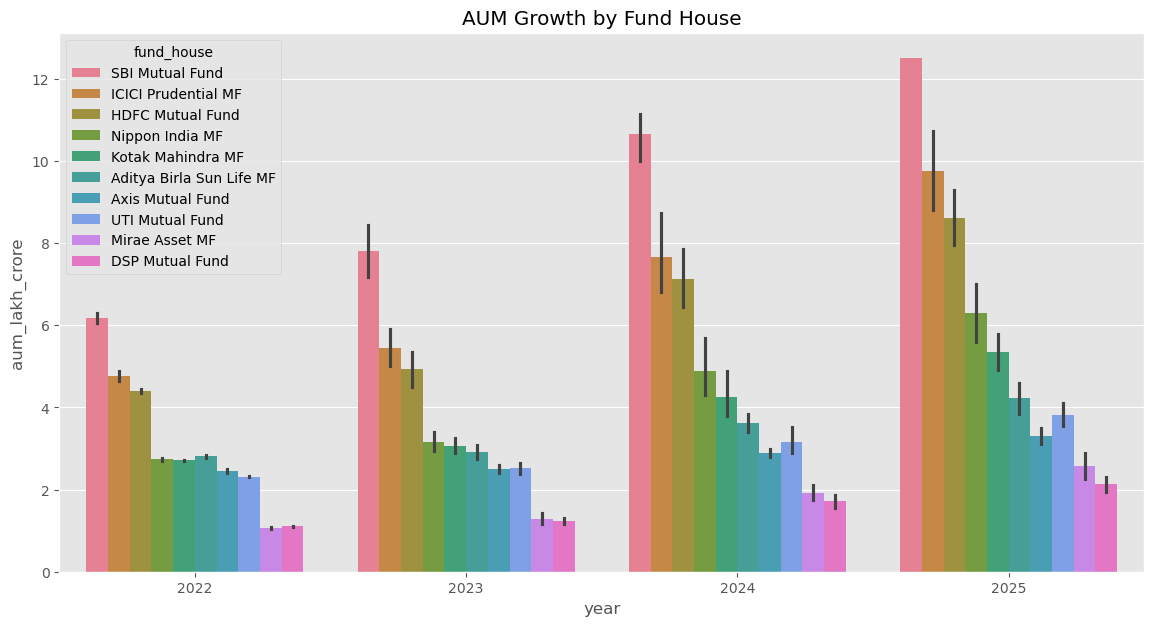

In [17]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
plt.figure(figsize=(14,7))
sns.barplot(data=aum, x="year", y="aum_lakh_crore", hue="fund_house")
plt.title("AUM Growth by Fund House")
plt.show()
fig.write_image("../reports/aum_growth.png")

In [18]:
sip["month"] = pd.to_datetime(sip["month"])
fig = px.line(sip, x="month", y="sip_inflow_crore", title="Monthly SIP Inflows")
fig.show()
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
print(peak)
fig.write_image("../reports/sip_trend.png")

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


Index(['month', 'category', 'net_inflow_crore'], dtype='object')


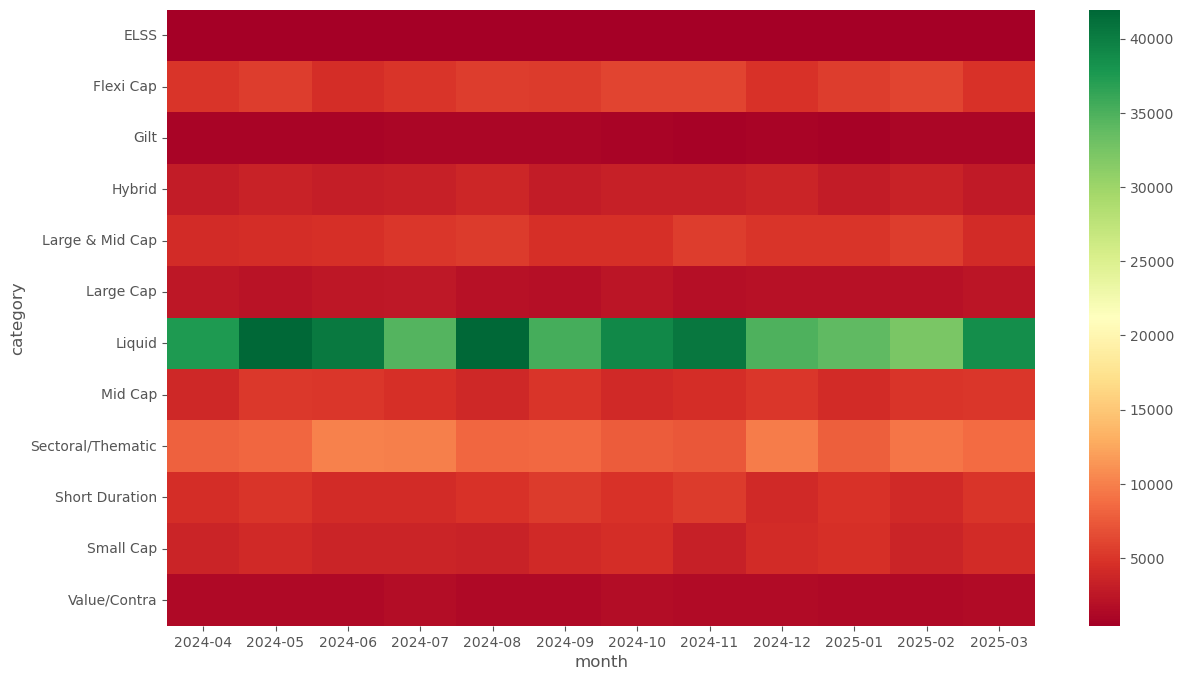

In [19]:
print(cat.columns)
pivot = cat.pivot(index="category", columns="month", values="net_inflow_crore")
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="RdYlGn")
plt.show()
fig.write_image("../reports/category_heatmap.png")

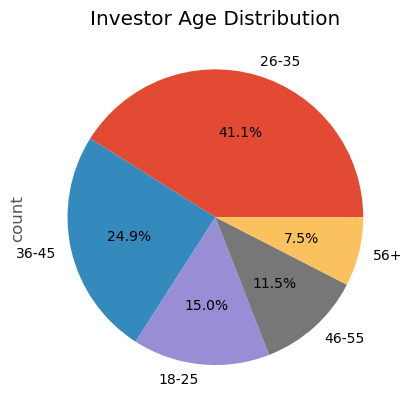

In [27]:
tx["age_group"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Investor Age Distribution")
plt.show()
fig.write_image("../reports/age_distribution.png")

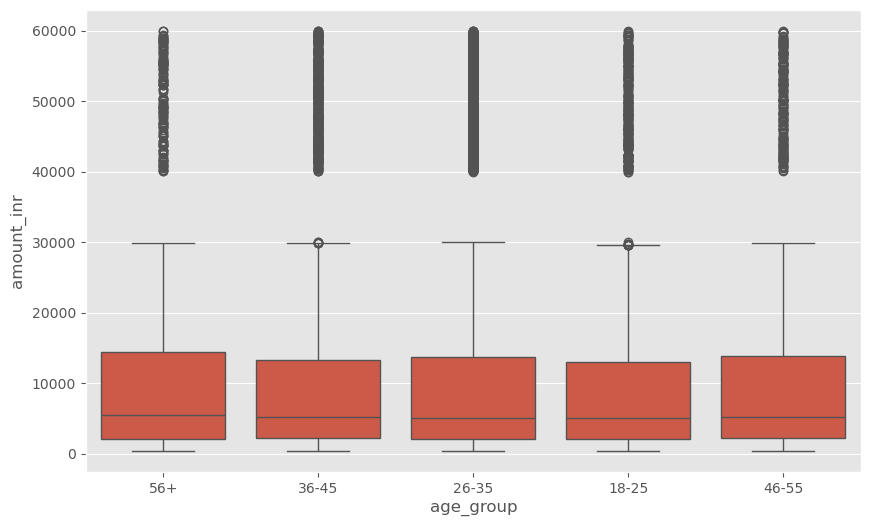

In [29]:
sip_tx = tx[tx["transaction_type"] == "SIP"]
plt.figure(figsize=(10,6))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr")
plt.show()
fig.write_image("../reports/sip_by_age.png")

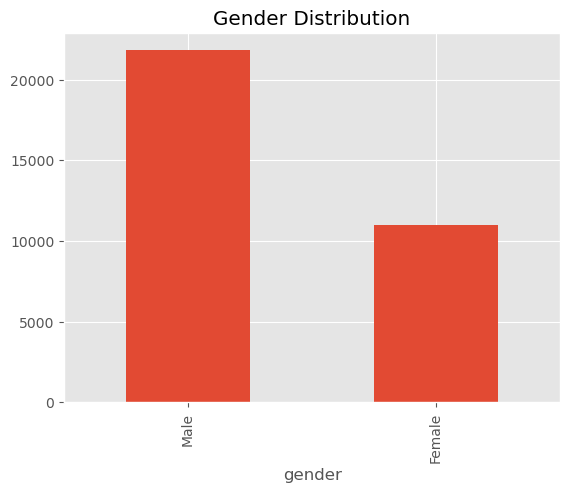

In [30]:
tx["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()
fig.write_image("../reports/gender_split.png")

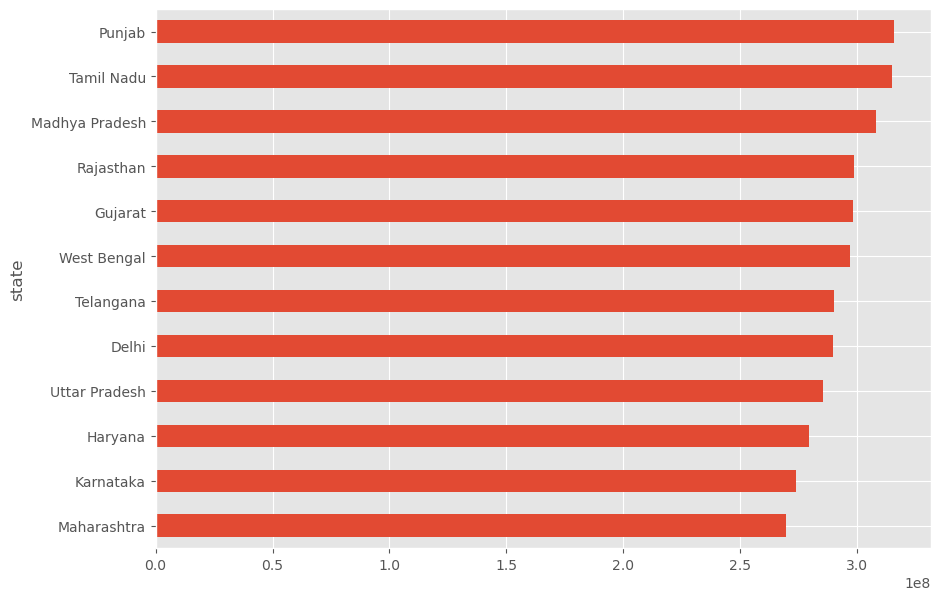

In [31]:
state_data = (tx.groupby("state")["amount_inr"].sum().sort_values())
state_data.plot(kind="barh", figsize=(10,7))
plt.show()
fig.write_image("../reports/state_distribution.png")

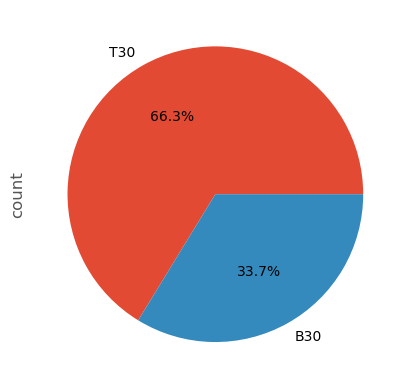

In [32]:
tx["city_tier"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.show()
fig.write_image("../reports/t30_b30_split.png")

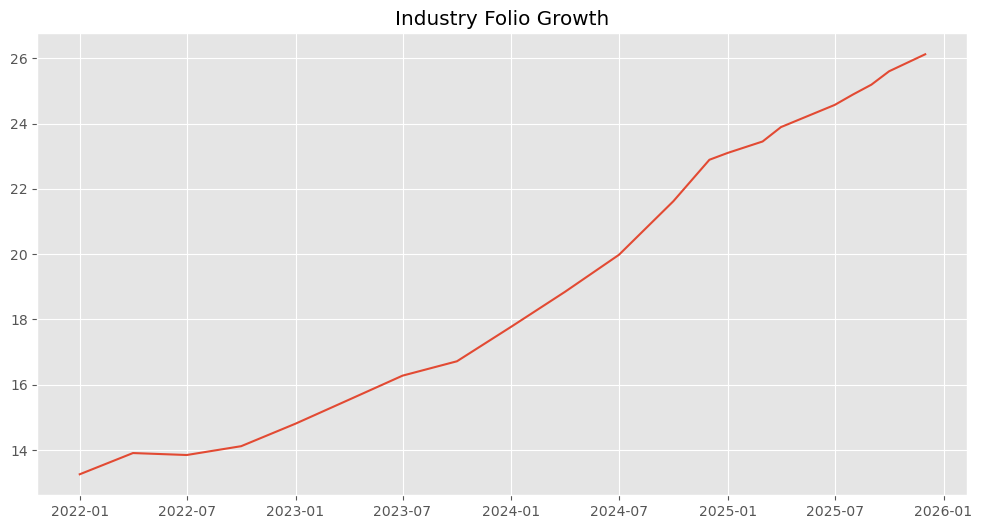

In [25]:
folio["month"] = pd.to_datetime(folio["month"])
plt.figure(figsize=(12,6))
plt.plot(folio["month"], folio["total_folios_crore"])
plt.title("Industry Folio Growth")
plt.show()
fig.write_image("../reports/folio_growth.png")

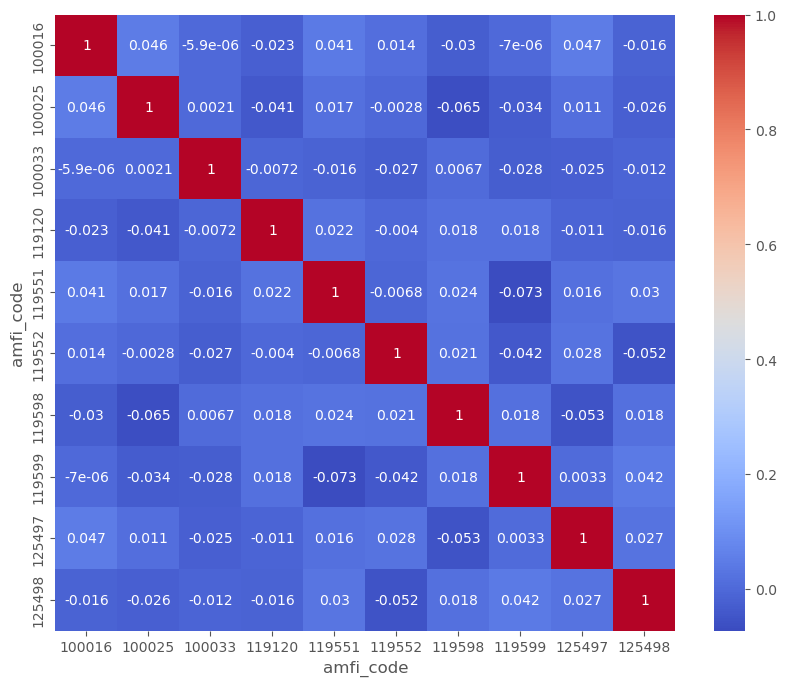

In [26]:
top10 = (nav["amfi_code"].unique()[:10])
pivot = nav[nav["amfi_code"].isin(top10)]
pivot = pivot.pivot(index="date", columns="amfi_code", values="nav")
returns = pivot.pct_change()
corr = returns.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
fig.write_image("../reports/correlation_matrix.png")

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


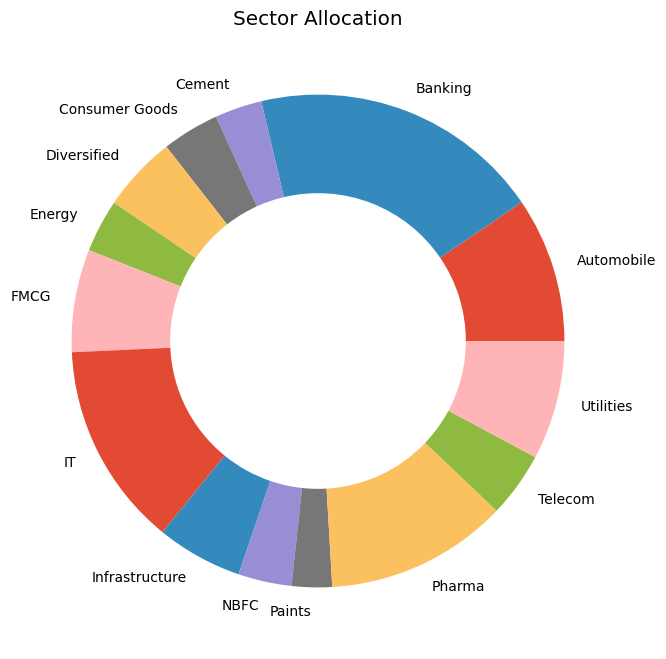

In [24]:
print(hold.columns)
sector = (hold.groupby("sector")["weight_pct"].sum())
plt.figure(figsize=(8,8))
plt.pie(sector, labels=list(sector.index), wedgeprops=dict(width=0.4))
plt.title("Sector Allocation")
plt.show()
fig.write_image("../reports/sector_allocation.png")